# 📊 Student Performance Prediction Using Machine Learning
This project predicts student academic performance using various machine learning algorithms.

## Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Load Dataset

In [13]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anilpachar/students-performance-dataset/StudentsPerformance.csv


In [15]:
import pandas as pd

data = pd.read_csv("/kaggle/input/datasets/anilpachar/students-performance-dataset/StudentsPerformance.csv")

data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Dataset Information

In [16]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Check Missing Values

In [17]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## Data Visualization

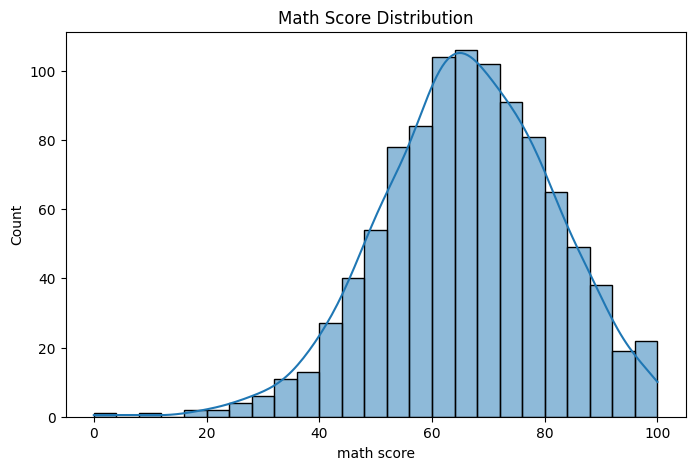

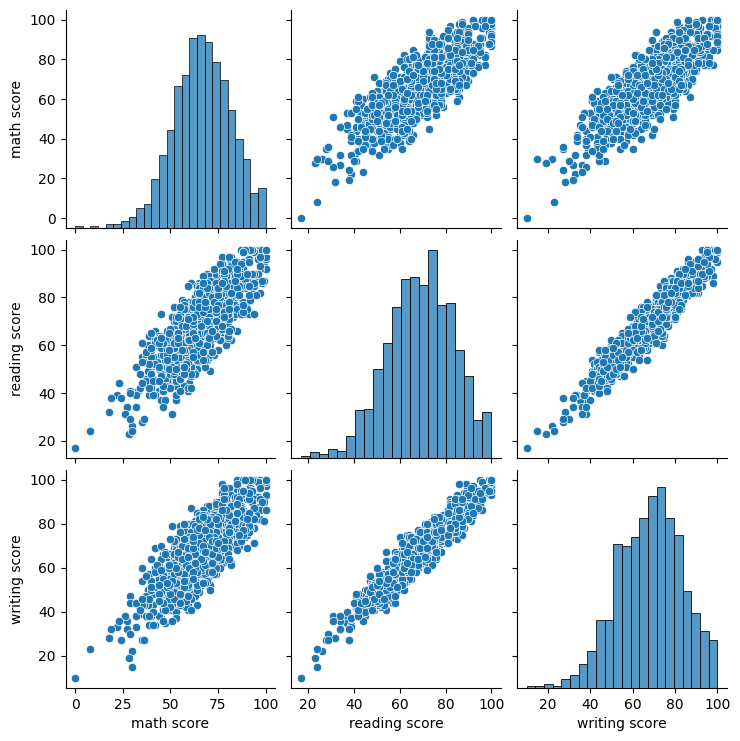

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(data['math score'], kde=True)
plt.title("Math Score Distribution")
plt.show()

sns.pairplot(data)
plt.show()

## Feature Engineering

In [21]:
data['average_score'] = (
    data['math score'] + 
    data['reading score'] + 
    data['writing score']
) / 3

## Encode Categorical Feature

In [22]:
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])

## Define Feature and Target

In [23]:
X = data.drop('average_score', axis=1)
y = data['average_score']

## Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Linear Regression Model

In [26]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

## Linear Regression Evaluation

In [27]:
print("Linear Regression Results")

mse = mean_squared_error(y_test, lr_pred)
r2 = r2_score(y_test, lr_pred)

print("MSE:", mse)
print("R2 Score:", r2)

Linear Regression Results
MSE: 3.142190757676334e-28
R2 Score: 1.0


## Random Forest Model

In [28]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Random Forest Evalution

In [29]:
print("Random Forest Results")

mse_rf = mean_squared_error(y_test, rf_pred)
r2_rf = r2_score(y_test, rf_pred)

print("MSE:", mse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MSE: 1.284999555555549
R2 Score: 0.9940055971622026


## Feature Importance

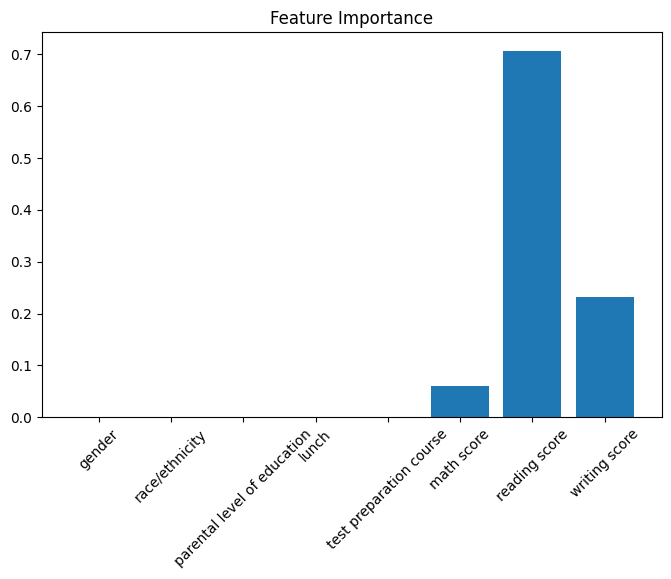

In [30]:
importance = rf.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

## Actual vs Predicted Graph

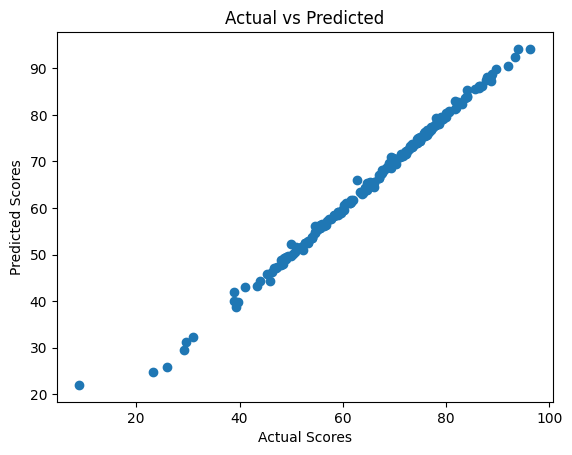

In [31]:
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.show()

## Prediction System

In [32]:
sample = X.iloc[0].values.reshape(1, -1)

prediction = rf.predict(sample)

print("Predicted Score:", prediction[0])

Predicted Score: 72.73000000000008


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


##  Import More Libraries 


In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, GridSearchCV

## Train Multiple Models

In [35]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Support Vector": SVR()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    results[name] = r2
    
    print(f"{name} R2 Score:", r2)

Linear Regression R2 Score: 1.0
Decision Tree R2 Score: 0.9873632864909334
Random Forest R2 Score: 0.994456577520821
Support Vector R2 Score: 0.9579479545991321


## Model Comparison Graph

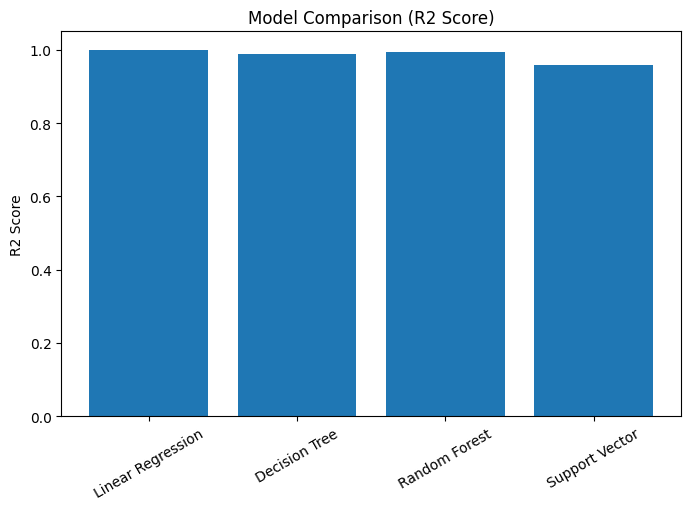

In [36]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

## Cross Validation

In [37]:
rf = RandomForestRegressor()

scores = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.99452974 0.99706993 0.99636127 0.9973106  0.99786047]
Average CV Score: 0.9966264019117389


## Hyperparameter Tuning

In [38]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 200}


## Train Best Model

In [39]:
best_model = grid.best_estimator_

best_pred = best_model.predict(X_test)

print("Final R2 Score:", r2_score(y_test, best_pred))

Final R2 Score: 0.9940184551137228


## Feature Importance

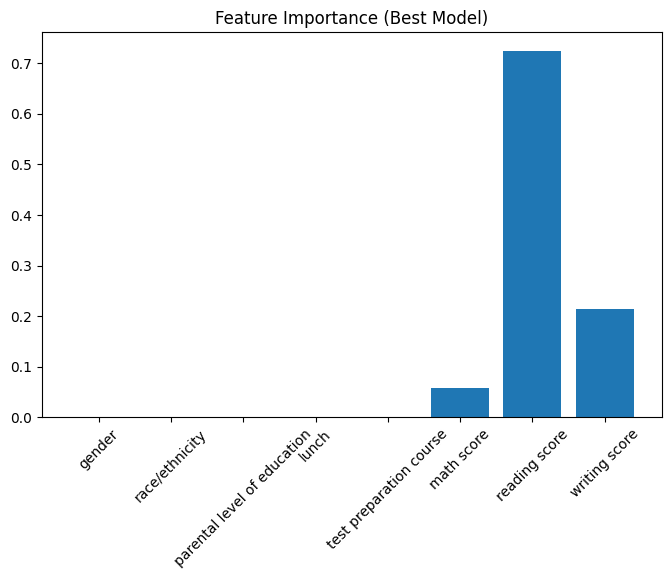

In [40]:
importance = best_model.feature_importances_

plt.figure(figsize=(8,5))
plt.bar(X.columns, importance)
plt.xticks(rotation=45)
plt.title("Feature Importance (Best Model)")
plt.show()

## Final Prediction System

In [41]:
sample = X.iloc[0].values.reshape(1, -1)

prediction = best_model.predict(sample)

print("Predicted Score:", prediction[0])

Predicted Score: 72.63712314986203


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


## Save Best Model

In [42]:
import joblib

joblib.dump(best_model, "best_student_model.pkl")

['best_student_model.pkl']